In [ ]:

import pandas as pd

df = pd.read_csv("eu-ai.csv", index_col=0)
print("INDEX (rows):")
print(df.index)
print("\nCOLUMNS (countries):")
print(df.columns)
print("\nHEAD:")
print(df.head())


INDEX (rows):
Index(['Very important', 'Fairly important', 'Not very important',
       'Not at all important', 'Don't know'],
      dtype='object')

COLUMNS (countries):
Index(['BE', 'BG', 'CZ', 'DK', 'D-W', 'DE', 'D-E', 'EE', 'IE', 'EL', 'ES',
       'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL',
       'PT', 'RO', 'SI', 'SK', 'FI', 'SE', 'EU27'],
      dtype='object')

HEAD:
                       BE   BG   CZ   DK  D-W   DE  D-E   EE   IE   EL  ...  \
Very important        367  430  338  526  442  555  113  320  558  394  ...   
Fairly important      483  381  391  336  494  609  115  382  315  418  ...   
Not very important    140  126  173   61  154  189   34  158   54   68  ...   
Not at all important   37   47   47   25   52   61    9   69   21   23  ...   
Don't know             16   81   58   34   78  102   24   78   57   97  ...   

                       NL   AT   PL   PT   RO   SI   SK   FI   SE   EU27  
Very important        557  381  201  320  21

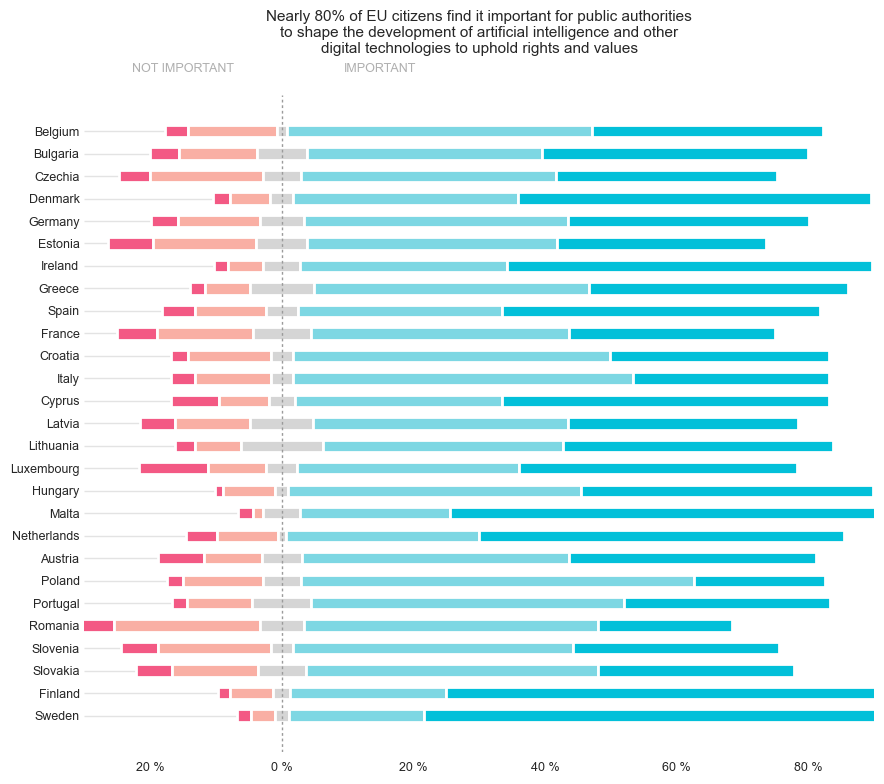

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white")

df = pd.read_csv("eu-ai.csv", index_col=0).apply(pd.to_numeric, errors="coerce")
pct = df.div(df.sum(axis=0), axis=1) * 100

code_to_name = {
    "BE":"Belgium","BG":"Bulgaria","CZ":"Czechia","DK":"Denmark","DE":"Germany","EE":"Estonia",
    "IE":"Ireland","EL":"Greece","ES":"Spain","FR":"France","HR":"Croatia","IT":"Italy","CY":"Cyprus",
    "LV":"Latvia","LT":"Lithuania","LU":"Luxembourg","HU":"Hungary","MT":"Malta","NL":"Netherlands",
    "AT":"Austria","PL":"Poland","PT":"Portugal","RO":"Romania","SI":"Slovenia","SK":"Slovakia",
    "FI":"Finland","SE":"Sweden"
}

order = [
    "Belgium","Bulgaria","Czechia","Denmark","Germany","Estonia","Ireland","Greece","Spain","France",
    "Croatia","Italy","Cyprus","Latvia","Lithuania","Luxembourg","Hungary","Malta","Netherlands",
    "Austria","Poland","Portugal","Romania","Slovenia","Slovakia","Finland","Sweden"
]

cols = [c for c in code_to_name if c in pct.columns]
data = pct[cols].rename(columns=code_to_name).T
data = data.loc[[c for c in order if c in data.index]]

c_very = "#02C0D9"
c_fairly = "#7DD7E3"
c_dk = "#D5D5D5"
c_notvery = "#F9AFA4"
c_notatall = "#F35984"

fig, ax = plt.subplots(figsize=(9, 8))
bar_h = 0.55
x_min, x_max = -30, 90

for i, country in enumerate(data.index):
    ax.hlines(i, x_min, 0, color="#E3E3E3", linewidth=1, zorder=0)

    v = float(data.loc[country, "Very important"])
    f = float(data.loc[country, "Fairly important"])
    nv = float(data.loc[country, "Not very important"])
    na = float(data.loc[country, "Not at all important"])
    dk = float(data.loc[country, "Don't know"])

    left_start = -(dk / 2 + na + nv)

    ax.barh(i, na, left=left_start, height=bar_h, color=c_notatall, edgecolor="white", linewidth=2)
    ax.barh(i, nv, left=left_start + na, height=bar_h, color=c_notvery, edgecolor="white", linewidth=2)
    ax.barh(i, dk, left=-dk / 2, height=bar_h, color=c_dk, edgecolor="white", linewidth=2)
    ax.barh(i, f, left=dk / 2, height=bar_h, color=c_fairly, edgecolor="white", linewidth=2)
    ax.barh(i, v, left=dk / 2 + f, height=bar_h, color=c_very, edgecolor="white", linewidth=2)

ax.axvline(0, color="#9B9B9B", linewidth=1, linestyle=(0, (2, 2)), zorder=5)

ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index, fontsize=9)
ax.invert_yaxis()

ticks = [-20, 0, 20, 40, 60, 80]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{abs(t)} %" for t in ticks], fontsize=9)
ax.set_xlim(x_min, x_max)

for s in ["top", "right", "left", "bottom"]:
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=4, color="#7A7A7A")

ax.set_title(
    "Nearly 80% of EU citizens find it important for public authorities\n"
    "to shape the development of artificial intelligence and other\n"
    "digital technologies to uphold rights and values",
    fontsize=11,
    pad=30,
)

ax.text(-15, 1.03, "NOT IMPORTANT", transform=ax.get_xaxis_transform(),
        ha="center", va="bottom", color="#B0B0B0", fontsize=9)
ax.text(15, 1.03, "IMPORTANT", transform=ax.get_xaxis_transform(),
        ha="center", va="bottom", color="#B0B0B0", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df2 = pd.read_csv("gen-ai.csv")

print("COLUMNS:")
print(df2.columns)

print("\nHEAD:")
print(df2.head())

print("\nDTYPES:")
print(df2.dtypes)

for c in df2.columns:
    if "occup" in c.lower() or "job" in c.lower() or "keyword" in c.lower() or "profession" in c.lower():
        print(f"\nUNIQUE VALUES in '{c}' (first 50):")
        print(df2[c].dropna().astype(str).unique()[:50])

COLUMNS:
Index(['occupation', 'man', 'woman', 'ambiguous', 'total'], dtype='object')

HEAD:
   occupation  man  woman  ambiguous  total
0   architect  237     56          7    300
1      lawyer  248     45          7    300
2  politician  271     23          6    300
3      doctor  262     20         18    300
4         ceo  281     16          3    300

DTYPES:
occupation    object
man            int64
woman          int64
ambiguous      int64
total          int64
dtype: object

UNIQUE VALUES in 'occupation' (first 50):
['architect' 'lawyer' 'politician' 'doctor' 'ceo' 'judge' 'engineer'
 'janitor' 'dishwasher' 'fast-food worker' 'cashier' 'teacher'
 'social worker' 'housekeeper']


In [ ]:
import sys
!{sys.executable} -m pip install pywaffle


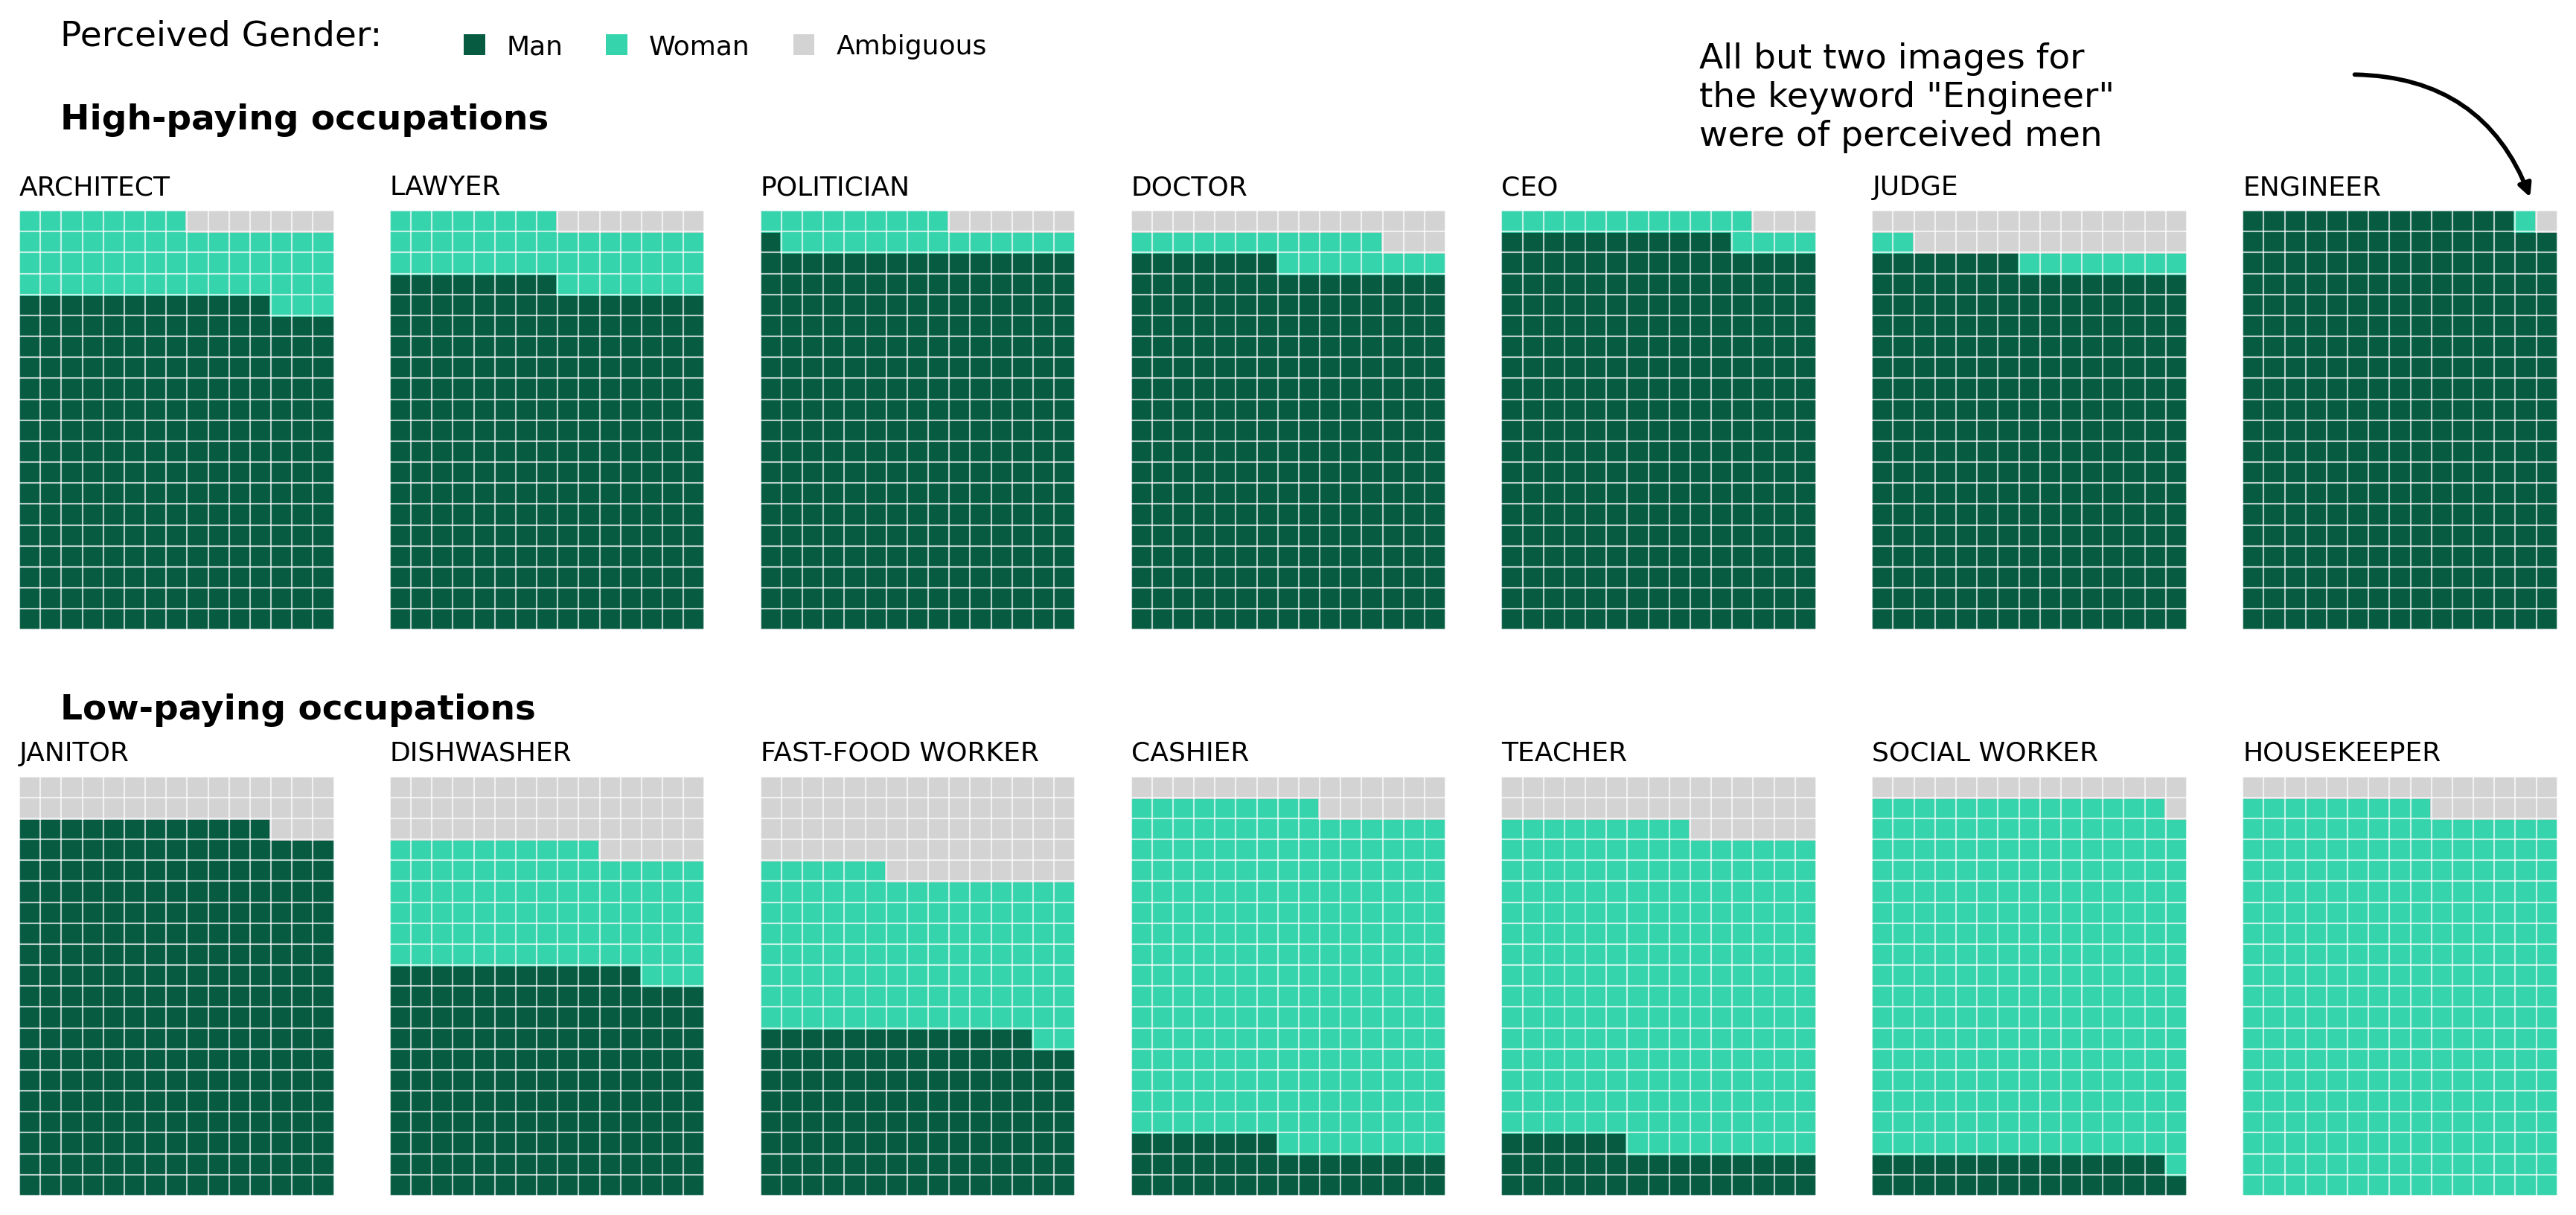

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pywaffle import Waffle
from matplotlib.patches import Patch

df = pd.read_csv("gen-ai.csv")

order = [
    "architect","lawyer","politician","doctor","ceo","judge","engineer",
    "janitor","dishwasher","fast-food worker","cashier","teacher","social worker","housekeeper"
]
sub = df.set_index("occupation").loc[order].reset_index()

ROWS, COLS = 20, 15

colors = ["#065B41", "#36D4AC", "#D3D3D3"]  # Man, Woman, Ambiguous

fig, axes = plt.subplots(2, 7, figsize=(14, 6.7), dpi=260)
axes = axes.flatten()

for ax, r in zip(axes, sub.itertuples(index=False)):
    Waffle.make_waffle(
        ax=ax,
        rows=ROWS,
        columns=COLS,
        values=[int(r.man), int(r.woman), int(r.ambiguous)],
        colors=colors,
        starting_location="SW",
        vertical=True,
        interval_ratio_x=0,
        interval_ratio_y=0,
        block_aspect_ratio=1,
    )

    ax.set_title(str(r.occupation).upper(), loc="left", pad=6, fontsize=10)
    ax.set_facecolor("white")
    ax.set_aspect("equal", adjustable="box")

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    xs = [x0 + (x1 - x0) * k / COLS for k in range(COLS + 1)]
    ys = [y0 + (y1 - y0) * k / ROWS for k in range(ROWS + 1)]
    ax.vlines(xs, y0, y1, colors="white", linewidth=0.6, alpha=0.7, zorder=10)
    ax.hlines(ys, x0, x1, colors="white", linewidth=0.6, alpha=0.7, zorder=10)

    ax.set_axis_off()

fig.patch.set_facecolor("white")
plt.subplots_adjust(left=0.04, right=0.985, top=0.83, bottom=0.07, wspace=0.10, hspace=0.35)

fig.text(0.055, 0.965, "Perceived Gender:", ha="left", va="center", fontsize=13)
handles = [
    Patch(facecolor=colors[0], edgecolor="none", label="Man"),
    Patch(facecolor=colors[1], edgecolor="none", label="Woman"),
    Patch(facecolor=colors[2], edgecolor="none", label="Ambiguous"),
]
fig.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(0.195, 0.985),
    frameon=False,
    ncol=3,
    handlelength=0.8,
    handleheight=0.8,
    columnspacing=1.6,
)

fig.text(0.055, 0.90, "High-paying occupations", ha="left", va="center", fontsize=13, fontweight="bold")
fig.text(0.055, 0.445, "Low-paying occupations", ha="left", va="center", fontsize=13, fontweight="bold")

fig.text(
    0.66,
    0.96,
    'All but two images for\nthe keyword "Engineer"\nwere of perceived men',
    ha="left",
    va="top",
    fontsize=13,
)

ax_engineer = axes[6]
ax_engineer.annotate(
    "",
    xy=(0.92, 1.02),
    xycoords=ax_engineer.transAxes,
    xytext=(0.90, 0.935),
    textcoords=fig.transFigure,
    arrowprops=dict(arrowstyle="-|>", lw=1.6, color="black", connectionstyle="arc3,rad=-0.35"),
)

plt.show()
